In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
df = pd.read_csv('/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.shape

(1067371, 8)

In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(34335)

In [10]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [11]:
df[df['Quantity'] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


# WE WILL CREATE TWO COPIES
Variable	Purpose

df	        original dataset
retail	    clean ML-ready dataset
returns_df	returns/cancellations dataset

# Create Main Copy

In [12]:
retail = df.copy()

# — Create Returns Dataset

In [13]:
returns_df = retail[
    (retail['Quantity'] < 0) |
    (retail['Invoice'].astype(str).str.startswith('C'))
]

# Remove Duplicates

In [14]:
retail.drop_duplicates(inplace=True)

In [15]:
retail.shape

(1033036, 8)

# Remove Missing Customer IDs

IMPORTANT for:

RFM
churn prediction
segmentation

In [16]:
retail = retail.dropna(subset=['Customer ID'])

# Fill Missing Descriptions

In [17]:
retail['Description'] = retail['Description'].fillna('Unknown')

# Remove Negative Quantity

In [18]:
retail = retail[retail['Quantity'] > 0]

# Remove Negative Prices

In [19]:
retail = retail[retail['Price'] > 0]

# Remove Cancelled Invoices

In [20]:
retail = retail[~retail['Invoice'].astype(str).str.startswith('C')]

# Convert Date Column

In [21]:
retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'])

# Create TotalPrice Column

In [22]:
retail['TotalPrice'] = retail['Quantity'] * retail['Price']

In [23]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  object        
 8   TotalPrice   779425 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 59.5+ MB


In [24]:
retail.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64

In [25]:
retail.shape

(779425, 9)

# Save Clean Dataset

In [26]:
retail.to_csv('cleaned_retail_data.csv', index=False)

# Save Returns Dataset

In [27]:
returns_df.to_csv('returns_data.csv', index=False)

# Data Cleaning Summary:

1. Created separate returns dataset
2. Removed duplicate rows
3. Removed missing customer IDs
4. Filled missing descriptions
5. Removed negative quantity transactions
6. Removed negative prices
7. Removed cancelled invoices
8. Converted InvoiceDate to datetime
9. Created TotalPrice feature

# Data VIsualization

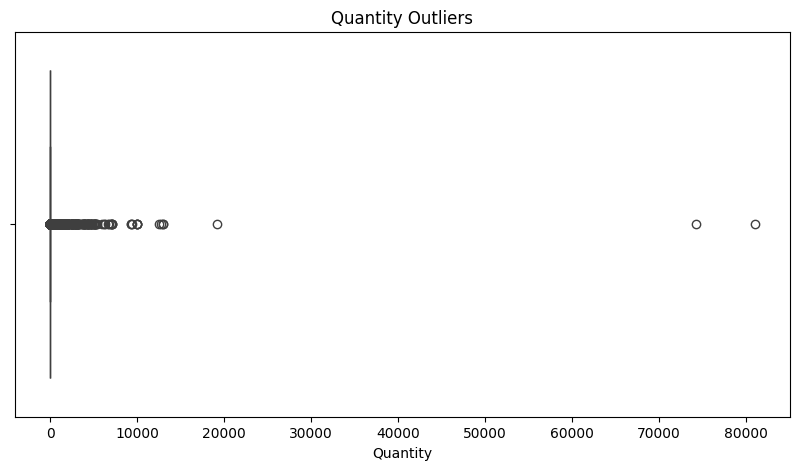

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x=retail['Quantity'])

plt.title("Quantity Outliers")
plt.show()

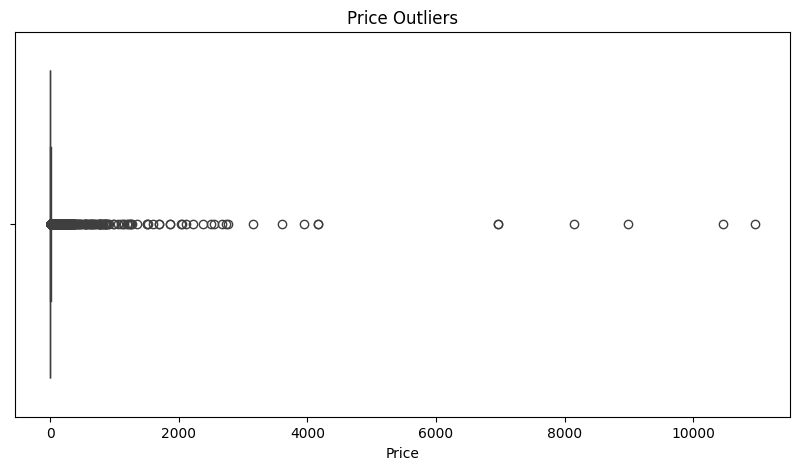

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(x=retail['Price'])

plt.title("Price Outliers")
plt.show()

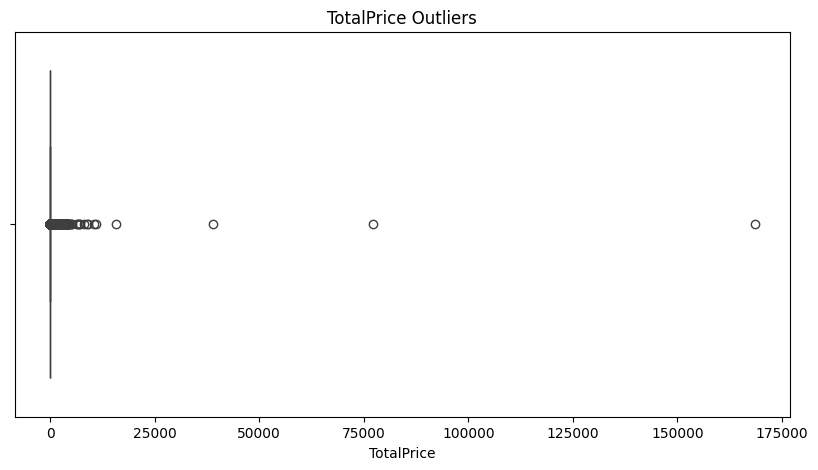

In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(x=retail['TotalPrice'])

plt.title("TotalPrice Outliers")
plt.show()

In [31]:
Q1 = retail['Quantity'].quantile(0.25)
Q3 = retail['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -13.0
Upper Bound: 27.0


In [32]:
outliers = retail[
    (retail['Quantity'] < lower_bound) |
    (retail['Quantity'] > upper_bound)
]

outliers.shape

(51119, 9)

IQR-based outlier detection identified 51,119 quantity outliers outside the range [-13, 27].

However, these transactions were retained because retail businesses naturally contain bulk purchases and wholesale orders. Removing them could distort actual sales behavior and forecasting patterns.

# EDA

In [33]:
retail['TotalPrice'].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

In [34]:
total_revenue = retail['TotalPrice'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 17374804.268000003


In [35]:
total_orders = retail['Invoice'].nunique()

print("Total Orders:", total_orders)

Total Orders: 36969


In [36]:
total_customers = retail['Customer ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 5878


In [37]:
total_products = retail['StockCode'].nunique()

print("Total Products:", total_products)

Total Products: 4631


In [38]:
summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Orders',
        'Total Customers',
        'Total Products'
    ],
    
    'Value': [
        total_revenue,
        total_orders,
        total_customers,
        total_products
    ]
})

summary

,Metric,Value
0,Total Revenue,1.737480e+07
1,Total Orders,3.696900e+04
2,Total Customers,5.878000e+03
3,Total Products,4.631000e+03


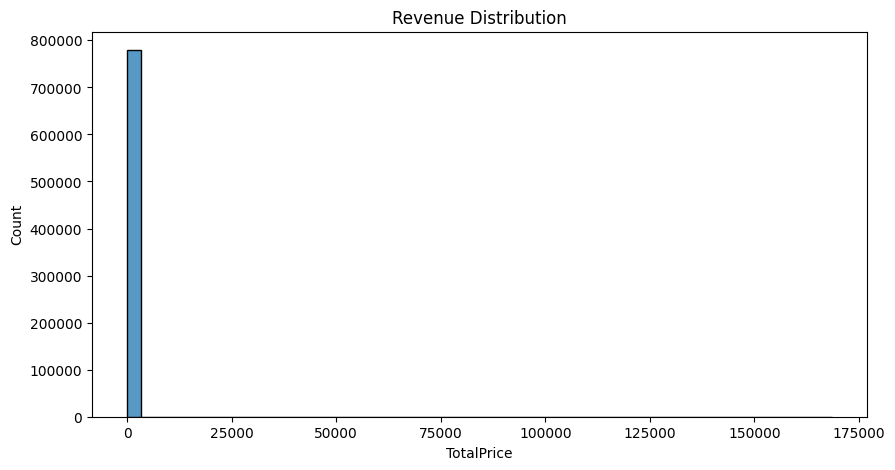

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(retail['TotalPrice'], bins=50)

plt.title("Revenue Distribution")
plt.show()

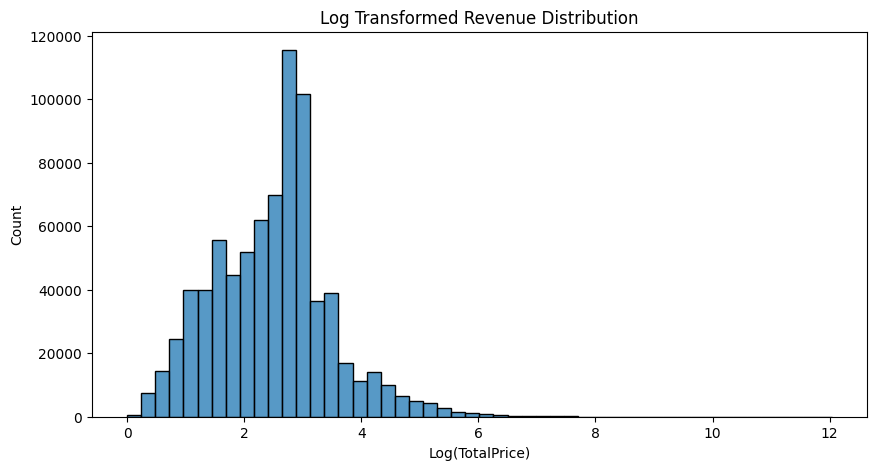

In [40]:
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(retail['TotalPrice']), bins=50)

plt.title("Log Transformed Revenue Distribution")

plt.xlabel("Log(TotalPrice)")

plt.show()

# Top Selling Products Analysis

In [41]:
top_products = retail.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64

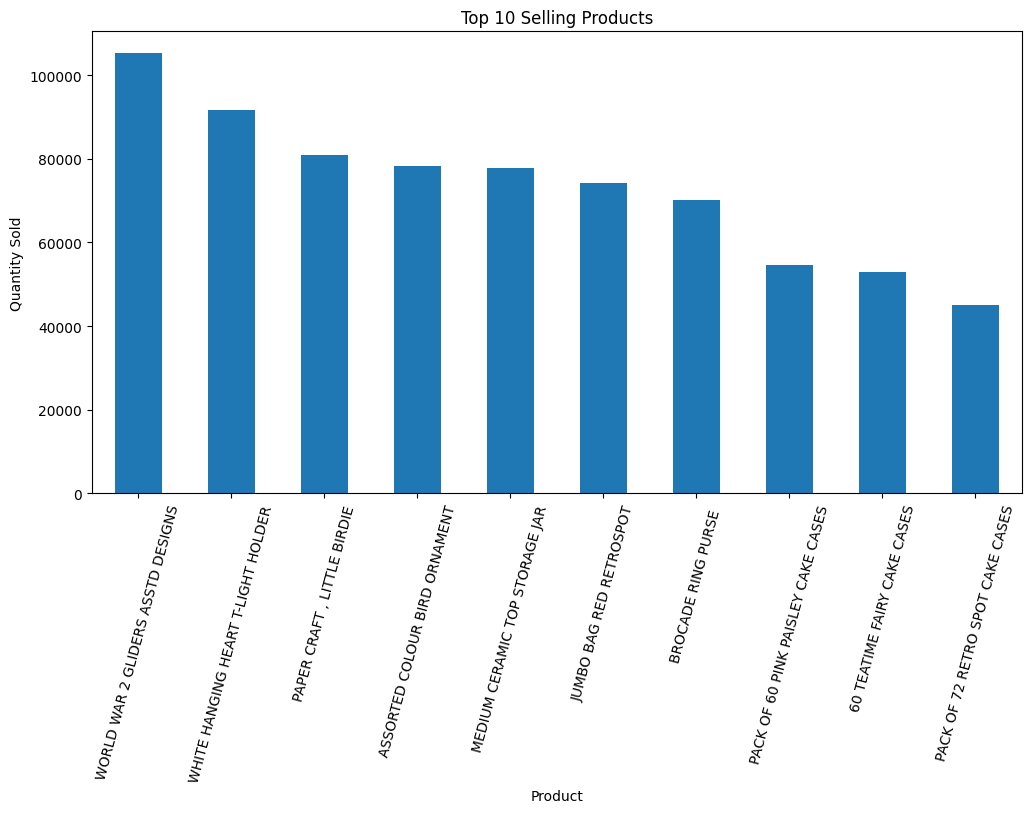

In [42]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")

plt.xlabel("Product")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=75)

plt.show()

Top-selling products were identified based on total quantity sold.

These products represent high-demand inventory items and can be prioritized for stock optimization and demand forecasting.

# Top Revenue Generating Products

In [43]:
top_revenue_products = retail.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_revenue_products

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: TotalPrice, dtype: float64

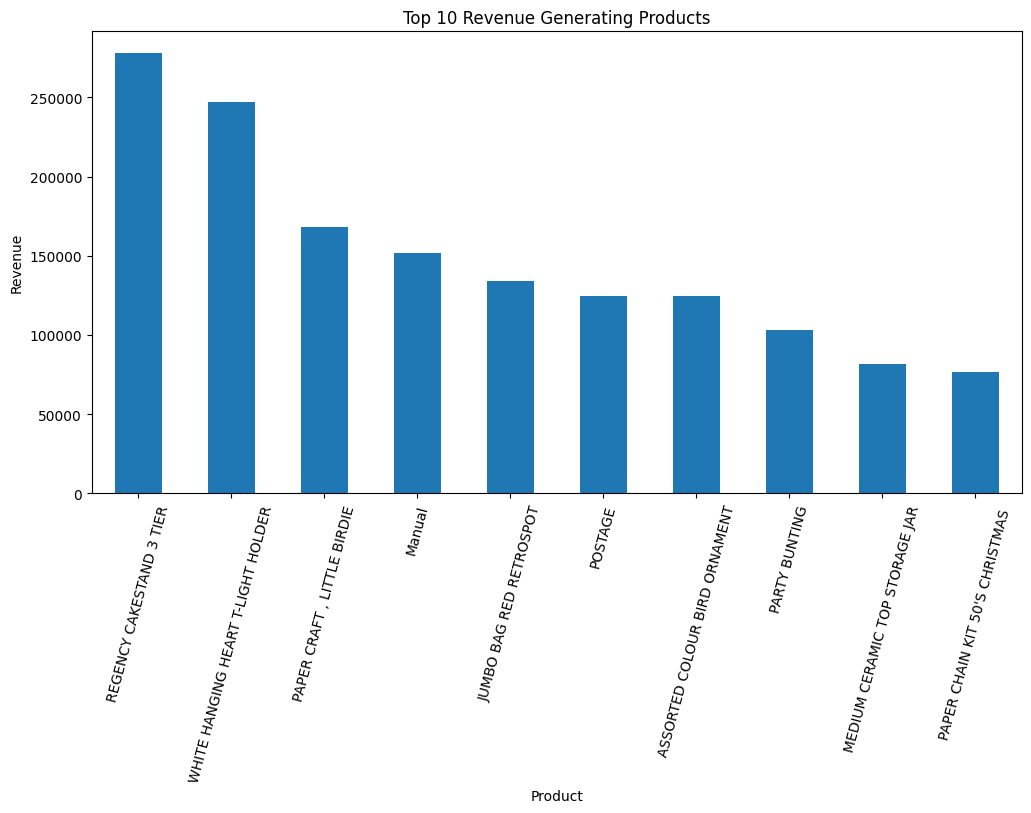

In [44]:
plt.figure(figsize=(12,6))

top_revenue_products.plot(kind='bar')

plt.title("Top 10 Revenue Generating Products")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.xticks(rotation=75)

plt.show()

Top revenue-generating products were identified using total sales revenue.

The analysis shows that highly profitable products are not always the most frequently purchased products, highlighting the importance of both sales volume and pricing strategy.

# Top Countries Analysis by revenue

In [45]:
top_countries = retail.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_countries

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: TotalPrice, dtype: float64

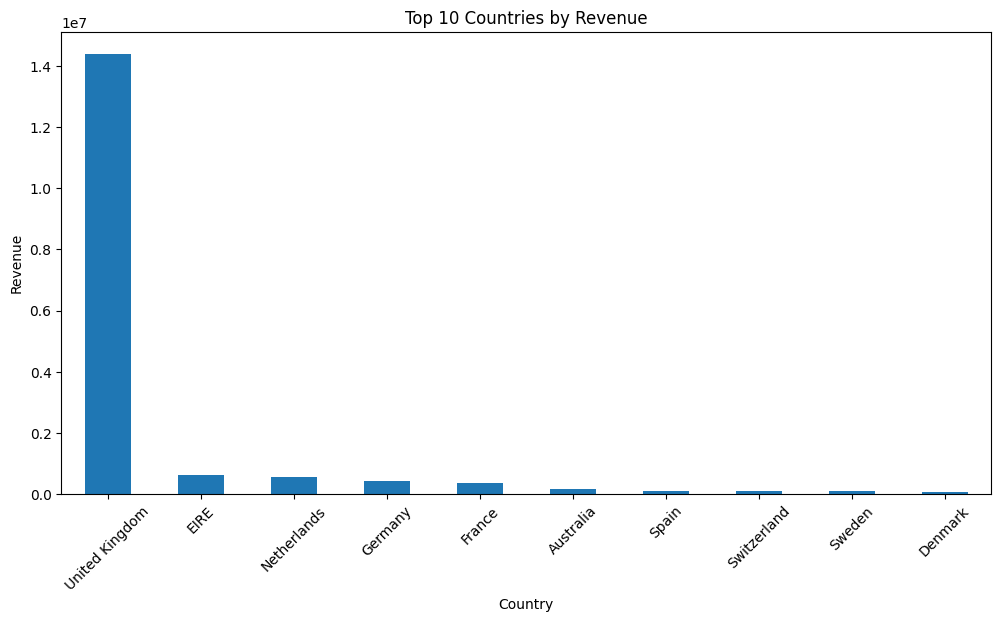

In [46]:
plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

Country-wise revenue analysis shows that the United Kingdom contributes the highest share of revenue, indicating strong domestic sales dominance.

International markets also contribute significantly to total sales, highlighting global customer reach.

# Monthly Sales Trend Analysis

Create YearMonth Column

In [47]:
retail['YearMonth'] = retail['InvoiceDate'].dt.to_period('M')

Monthly Revenue

In [48]:
monthly_sales = retail.groupby('YearMonth')['TotalPrice'].sum()

monthly_sales

YearMonth
2009-12     683504.010
2010-01     555802.672
2010-02     504558.956
2010-03     696978.471
2010-04     591982.002
2010-05     597833.380
2010-06     636371.130
2010-07     589736.170
2010-08     602224.600
2010-09     829013.951
2010-10    1033112.010
2010-11    1166460.022
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517208.440
Freq: M, Name: TotalPrice, dtype: float64

Convert Index To String

In [49]:
monthly_sales.index = monthly_sales.index.astype(str)

Plot Monthly Sales Trend

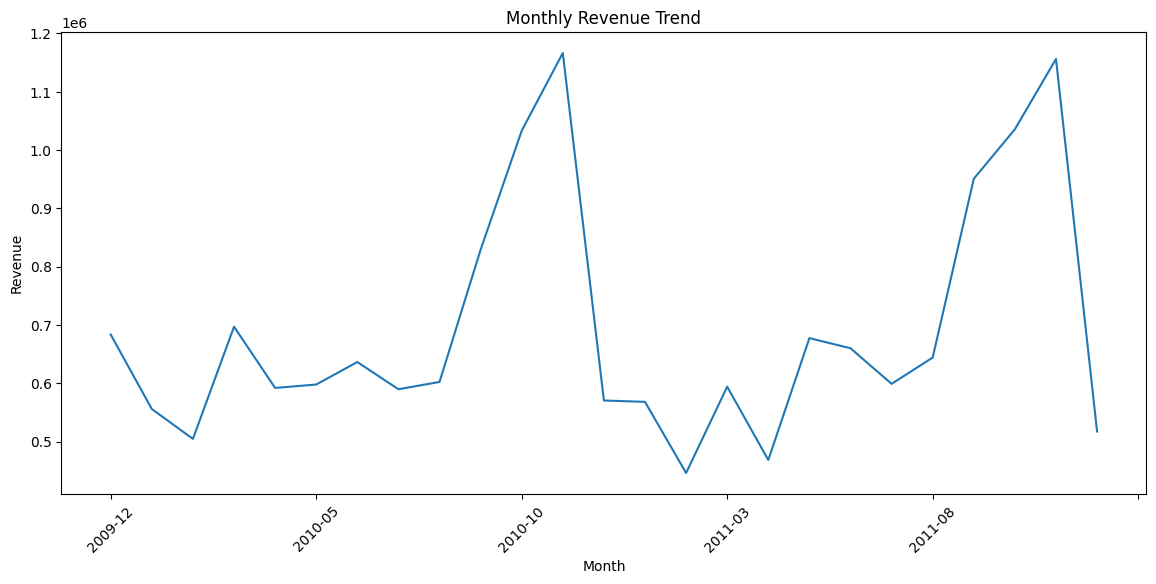

In [50]:
plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

Monthly revenue analysis reveals sales trends and seasonality patterns over time.

Certain months show significant revenue spikes, indicating seasonal shopping behavior and peak retail demand periods.

# Top Customers Analysis

In [51]:
top_customers = retail.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_customers

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: TotalPrice, dtype: float64

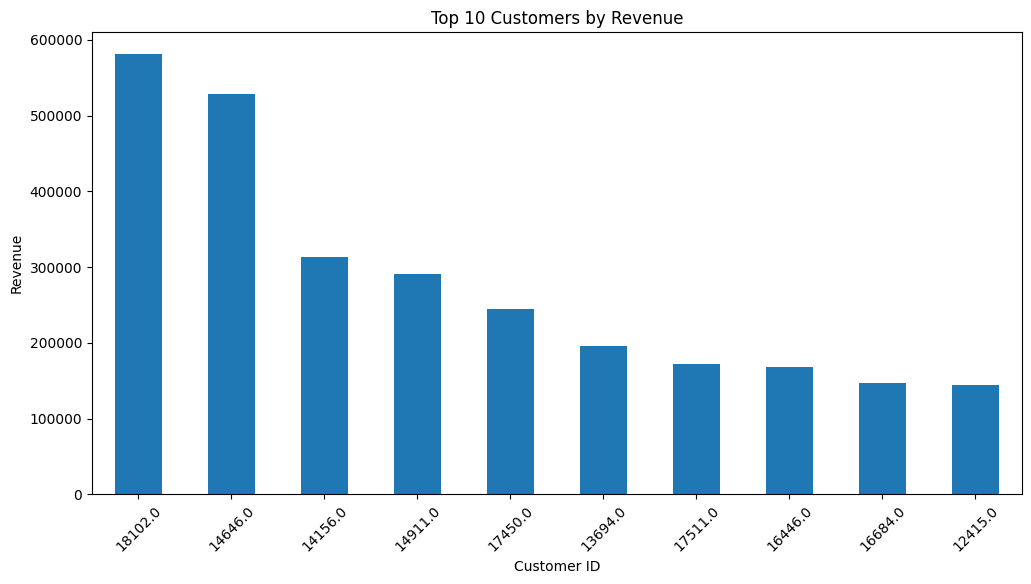

In [52]:
plt.figure(figsize=(12,6))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Customer ID")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

Top customer analysis shows that a small group of customers contributes a significant portion of total revenue.

These high-value customers are critical for customer retention strategies and personalized marketing campaigns.

# RFM Analysis
customer segmentation,
churn understanding,
customer value analysis

RFM Analysis is a customer segmentation technique used to identify valuable customers based on their purchasing behavior.

RFM stands for:

- Recency → How recently a customer made a purchase
- Frequency → How often a customer makes purchases
- Monetary → How much money a customer spends

This analysis helps businesses identify:
- VIP customers
- Loyal customers
- At-risk customers
- Inactive customers

RFM analysis is widely used in customer retention, churn prediction, and personalized marketing strategies.



# Find Latest Date

In [53]:
 snapshot_date = retail['InvoiceDate'].max()

snapshot_date

Timestamp('2011-12-09 12:50:00')


The latest transaction date in the dataset is used as the reference point for calculating customer recency.

# Create RFM Table

In [54]:
rfm = retail.groupby('Customer ID').agg({
    
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    
    'Invoice': 'nunique',
    
    'TotalPrice': 'sum'
})

The RFM table was generated by grouping transactions by Customer ID and calculating:

- Recency → Days since last purchase
- Frequency → Number of unique orders
- Monetary → Total customer spending

In [55]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [56]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,77556.46
12347.0,1,8,4921.53
12348.0,74,5,2019.40
12349.0,18,4,4428.69
12350.0,309,1,334.40


# RFM Statistics

In [57]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,342.280000
50%,95.000000,3.000000,867.740000
75%,379.000000,7.000000,2248.305000
max,738.000000,398.000000,580987.040000


The RFM summary statistics provide insights into customer purchasing behavior, spending patterns, and customer activity levels across the retail platform.

# RFM Scoring

In [58]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [59]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [60]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [61]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [62]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,325,12,77556.46,2,4,4,244
12347.0,1,8,4921.53,4,4,4,444
12348.0,74,5,2019.40,3,3,3,333
12349.0,18,4,4428.69,4,3,4,434
12350.0,309,1,334.40,2,1,1,211


In [63]:
rfm['RFM_Score'].value_counts().head(10)

RFM_Score
444    659
111    571
344    345
211    253
233    228
333    224
222    218
433    213
122    209
112    161
Name: count, dtype: int64

# RFM Scoring

RFM scoring was performed using quartile-based segmentation to evaluate customer purchasing behavior.

Each customer was assigned scores for:

- Recency (R) → How recently the customer made a purchase
- Frequency (F) → How frequently the customer placed orders
- Monetary (M) → How much money the customer spent

Scoring Logic:
- Lower recency values received higher scores because recent customers are more engaged.
- Higher frequency values received higher scores because frequent buyers are more loyal.
- Higher monetary values received higher scores because high-spending customers contribute more revenue.

Each metric was scored on a scale of 1 to 4 using quartiles.

The final RFM score was created by combining the individual R, F, and M scores.

Example:
- 444 → Best customers (recent, frequent, high-spending)
- 111 → Low-value or inactive customers

RFM scoring helps businesses identify:
- VIP customers
- Loyal customers
- At-risk customers
- Inactive customers

This analysis is widely used in customer retention strategies, churn analysis, personalized marketing, and customer segmentation.

# Customer Segmentation

Customers were segmented based on their RFM scores to identify different customer behavior patterns.

Segmentation Categories:
- VIP Customers → Highly active, frequent, and high-spending customers
- Loyal Customers → Frequent and recently active customers
- Potential Customers → Recently active customers with lower purchase frequency
- At Risk Customers → Previously frequent customers who have become inactive
- Regular Customers → Average purchasing behavior

Customer segmentation helps businesses improve:
- Personalized marketing
- Customer retention
- Loyalty programs
- Churn reduction strategies
- Revenue optimization

In [64]:
def customer_segment(row):
    
    if row['RFM_Score'] == '444':
        return 'VIP Customer'
    
    elif row['R_Score'] == 4 and row['F_Score'] >= 3:
        return 'Loyal Customer'
    
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2:
        return 'Potential Customer'
    
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk Customer'
    
    else:
        return 'Regular Customer'

In [65]:
rfm['Segment'] = rfm.apply(customer_segment, axis=1)

In [66]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,325,12,77556.46,2,4,4,244,At Risk Customer
12347.0,1,8,4921.53,4,4,4,444,VIP Customer
12348.0,74,5,2019.40,3,3,3,333,Regular Customer
12349.0,18,4,4428.69,4,3,4,434,Loyal Customer
12350.0,309,1,334.40,2,1,1,211,Regular Customer


In [67]:
rfm['Segment'].value_counts()

Segment
Regular Customer      2930
Potential Customer     894
At Risk Customer       880
VIP Customer           659
Loyal Customer         515
Name: count, dtype: int64

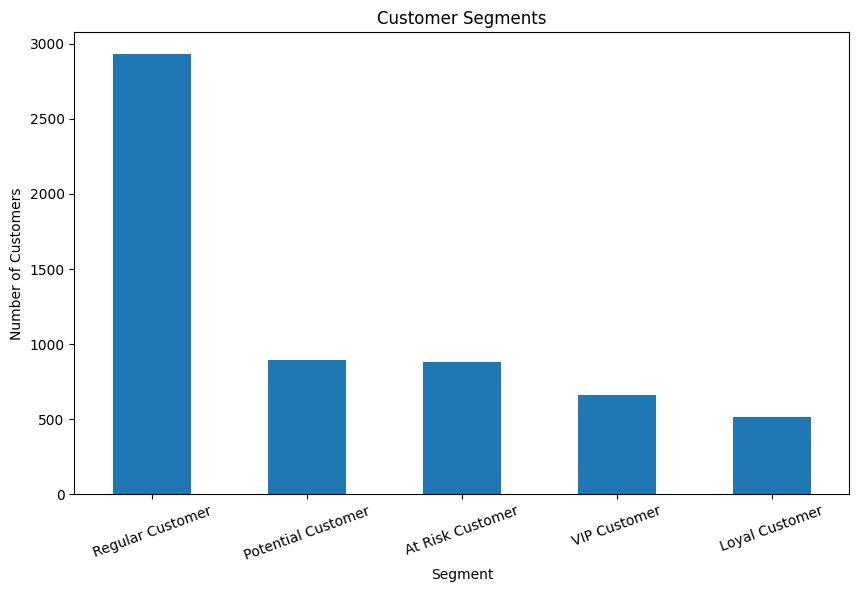

In [68]:
plt.figure(figsize=(10,6))

rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segments")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

# KMeans Clustering
# KMeans Customer Segmentation

KMeans clustering was applied to the RFM features to automatically group customers based on purchasing behavior.

Feature scaling was performed before clustering to ensure equal importance of Recency, Frequency, and Monetary values.

The Elbow Method was used to determine the optimal number of clusters, and 3 clusters were selected for segmentation.

The resulting clusters help identify different customer groups for targeted marketing and retention strategies.


In [69]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [70]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

In [71]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

In [72]:
inertia = []

for i in range(1,11):
    
    kmeans = KMeans(n_clusters=i, random_state=42)
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

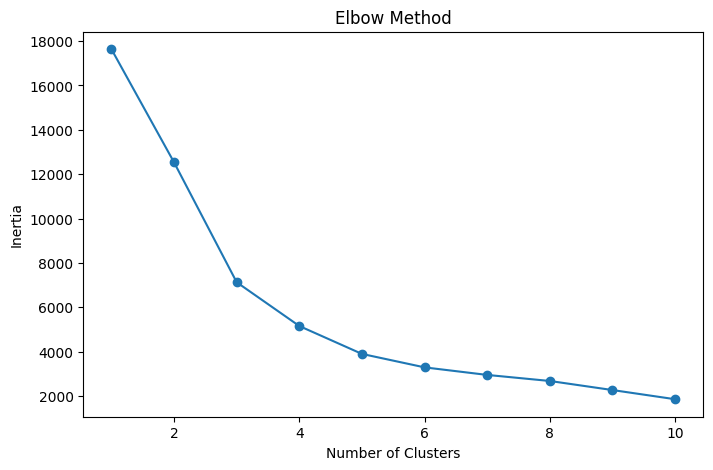

In [73]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

K = 3

WHY K=3?

Observe graph:

1 → 2 : huge drop
2 → 3 : huge drop
after 3 : curve slow ho gaya

In [74]:
# Train KMeans Model

kmeans = KMeans(n_clusters=3, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [75]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster
Customer ID,,,,,,,,,
12346.0,325,12,77556.46,2,4,4,244,At Risk Customer,1
12347.0,1,8,4921.53,4,4,4,444,VIP Customer,1
12348.0,74,5,2019.40,3,3,3,333,Regular Customer,1
12349.0,18,4,4428.69,4,3,4,434,Loyal Customer,1
12350.0,309,1,334.40,2,1,1,211,Regular Customer,0


In [76]:
rfm['Cluster'].value_counts()

Cluster
1    3846
0    2010
2      22
Name: count, dtype: int64

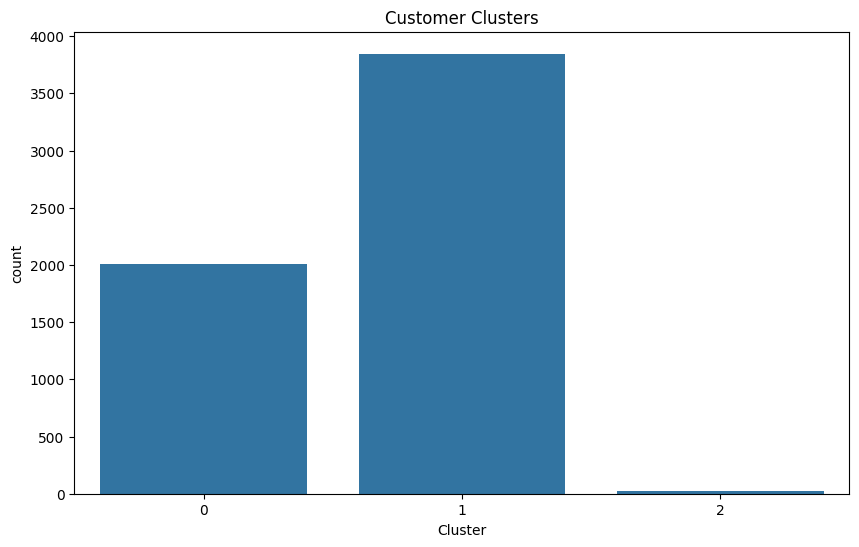

In [77]:
plt.figure(figsize=(10,6))

sns.countplot(x='Cluster', data=rfm)

plt.title("Customer Clusters")

plt.show()

In [78]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,460.784577,2.212438,748.384713
1,65.233489,7.637806,3136.201806
2,22.090909,143.045455,173123.584091


In [79]:
cluster_names = {
    0: 'At Risk Customers',
    1: 'Loyal Customers',
    2: 'VIP Customers'
}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_names)

In [80]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Cluster,Cluster_Label
Customer ID,,,,,,,,,,
12346.0,325,12,77556.46,2,4,4,244,At Risk Customer,1,Loyal Customers
12347.0,1,8,4921.53,4,4,4,444,VIP Customer,1,Loyal Customers
12348.0,74,5,2019.40,3,3,3,333,Regular Customer,1,Loyal Customers
12349.0,18,4,4428.69,4,3,4,434,Loyal Customer,1,Loyal Customers
12350.0,309,1,334.40,2,1,1,211,Regular Customer,0,At Risk Customers


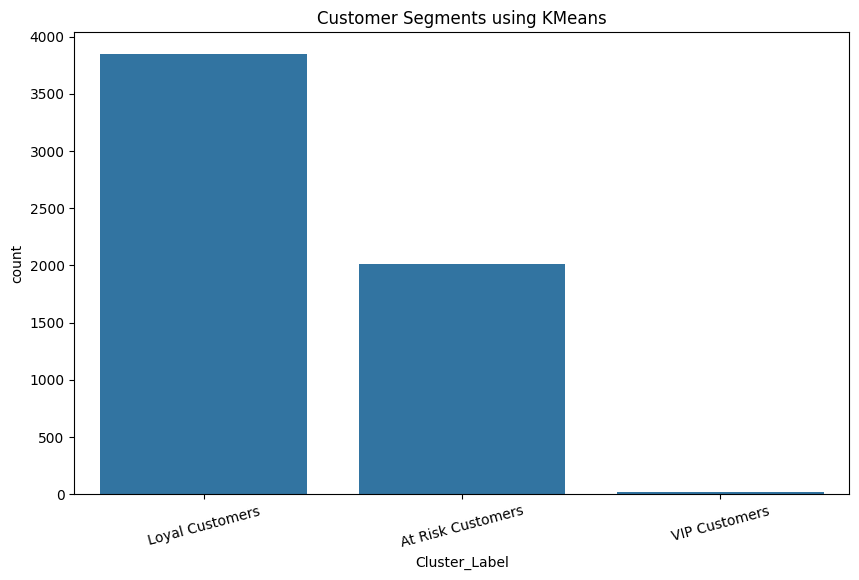

In [81]:
plt.figure(figsize=(10,6))

sns.countplot(x='Cluster_Label', data=rfm)

plt.title("Customer Segments using KMeans")

plt.xticks(rotation=15)

plt.show()

# KMeans Cluster Interpretation

Three customer clusters were identified using KMeans clustering on RFM features.

Cluster Insights:

- Cluster 0 → At Risk Customers
  Customers with very low purchase frequency, low spending, and long inactivity periods.

- Cluster 1 → Loyal Customers
  Customers with moderate recency, repeat purchasing behavior, and consistent spending.

- Cluster 2 → VIP Customers
  High-value customers with extremely high purchase frequency, recent activity, and significant revenue contribution.

The clustering results highlight that a small group of VIP customers contributes disproportionately to total revenue, reflecting the Pareto Principle commonly observed in retail businesses.

# Demand Forecasting using Prophet

A Prophet time-series forecasting model was used to predict future retail revenue trends.

Monthly sales revenue was aggregated and transformed into Prophet’s required format:
- ds → Date
- y → Revenue

The model captures:
- Trend patterns
- Seasonal behavior
- Future sales projections

Forecasting helps businesses improve:
- Inventory planning
- Demand estimation
- Revenue forecasting
- Supply chain optimization

In [82]:
!pip install prophet

In [83]:
from prophet import Prophet

Prepare Monthly Sales Data

Prophet ko:

2 columns chahiye:

Column	Meaning
ds	      date

y	      target value


In [84]:
forecast_data = retail.groupby('YearMonth')['TotalPrice'].sum().reset_index()

In [85]:
forecast_data['YearMonth'] = forecast_data['YearMonth'].astype(str)

In [86]:
forecast_data.columns = ['ds', 'y']

In [87]:
forecast_data['ds'] = pd.to_datetime(forecast_data['ds'])

In [88]:
forecast_data.head()

,ds,y
0,2009-12-01,683504.010
1,2010-01-01,555802.672
2,2010-02-01,504558.956
3,2010-03-01,696978.471
4,2010-04-01,591982.002


In [89]:
model = Prophet()

In [90]:
model.fit(forecast_data)

11:07:37 - cmdstanpy - INFO - Chain [1] start processing
11:07:38 - cmdstanpy - INFO - Chain [1] done processing


In [91]:
future = model.make_future_dataframe(periods=6, freq='M')

In [92]:
forecast = model.predict(future)

In [93]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
26,2012-01-31,532671.078379,523206.435897,541783.644338
27,2012-02-29,556367.281780,545749.503351,567495.175861
28,2012-03-31,378869.893720,365123.344951,391839.247177
29,2012-04-30,755526.435215,739026.038444,771664.251520
30,2012-05-31,642987.372818,621706.023828,663300.613078


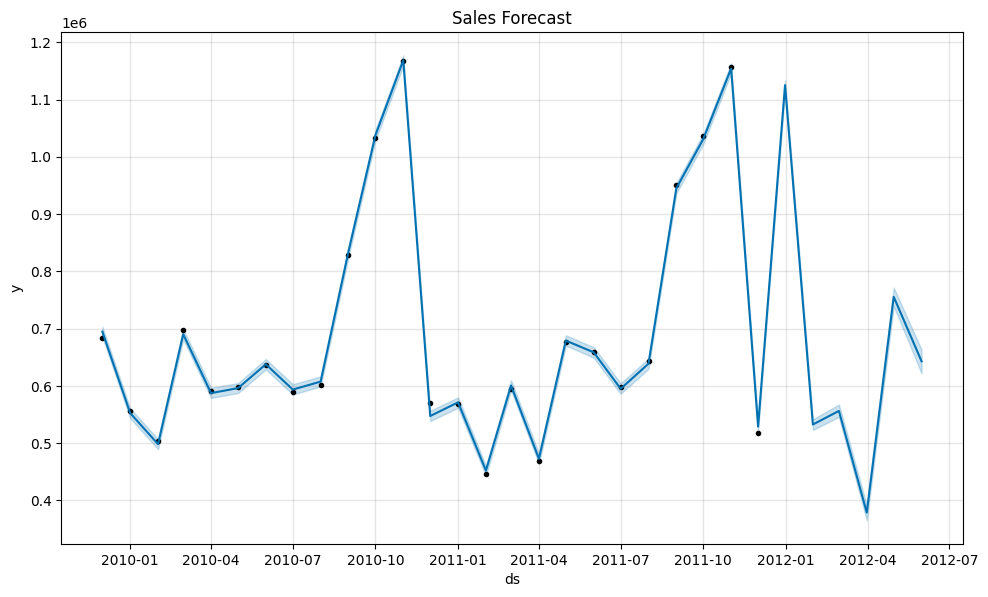

In [94]:
fig1 = model.plot(forecast)
plt.title("Sales Forecast")
plt.show()

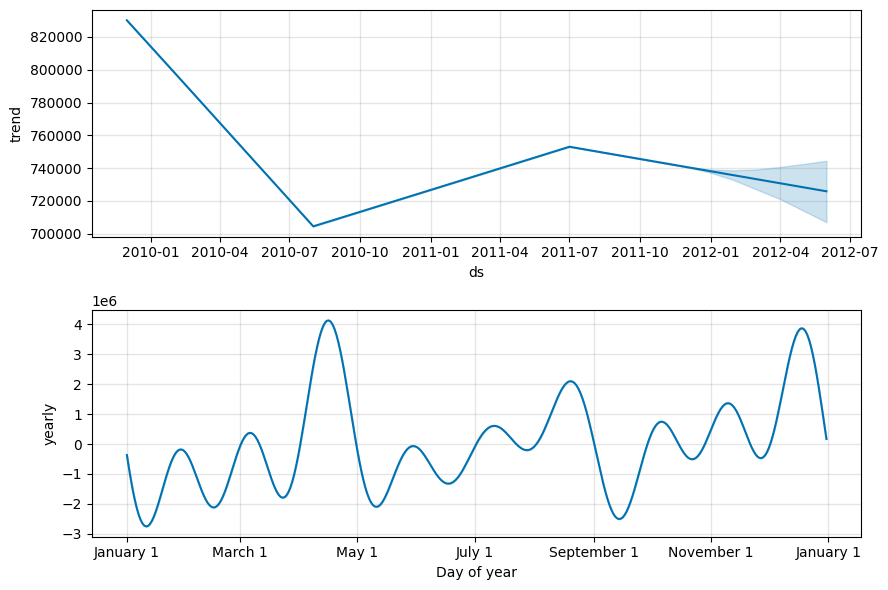

In [95]:
fig2 = model.plot_components(forecast)
plt.show()

# Saving Data

In [96]:
# Save Clean Dataset
retail.to_csv('cleaned_retail_data.csv', index=False)

In [97]:
# Save Returns Dataset
returns_df.to_csv('returns_data.csv', index=False)

In [98]:
# Save RFM Dataset

rfm.to_csv('rfm_customer_segments.csv', index=False)

In [99]:
#Save Forecast Results

forecast.to_csv('sales_forecast.csv', index=False)

# Churn Prediction

In [100]:
rfm['Churn'] = np.where(rfm['Recency'] > 90, 1, 0)

In [101]:
rfm['Churn'].value_counts()

Churn
1    2985
0    2893
Name: count, dtype: int64

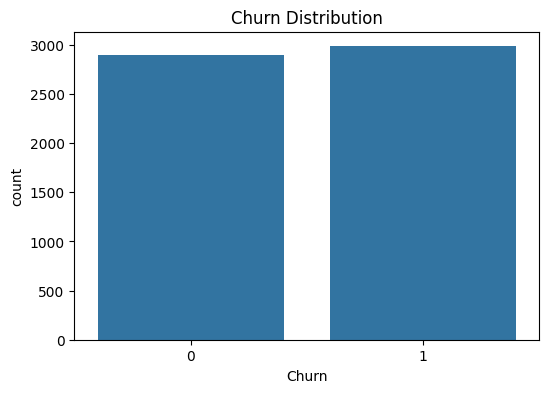

In [102]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=rfm)

plt.title("Churn Distribution")

plt.show()

In [103]:
X = rfm[['Frequency', 'Monetary']]

y = rfm['Churn']

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [106]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [107]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [108]:
xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [109]:
from sklearn.metrics import accuracy_score

In [110]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

Logistic Regression Accuracy: 0.6700680272108843
Random Forest Accuracy: 0.6147959183673469
XGBoost Accuracy: 0.6836734693877551


In [111]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.73      0.58      0.65       589
           1       0.65      0.79      0.71       587

    accuracy                           0.68      1176
   macro avg       0.69      0.68      0.68      1176
weighted avg       0.69      0.68      0.68      1176



In [112]:
rfm.to_csv('customer_churn_analysis.csv', index=False)

# Churn Model Evaluation

Three machine learning models were trained for churn prediction:
- Logistic Regression
- Random Forest
- XGBoost

Initially, perfect accuracy was observed due to data leakage caused by directly using the Recency feature for churn label creation.

To resolve this issue, the model was retrained using Frequency and Monetary features only.

XGBoost achieved the best performance with approximately 68% accuracy and strong recall for churn detection, making it the selected model for customer churn prediction.

The model demonstrates the ability to identify potentially inactive customers for retention and marketing strategies.

# Inventory Optimization 

In [113]:
inventory = retail.groupby('Description').agg({
    
    'Quantity': 'sum',
    
    'Invoice': 'nunique',
    
    'TotalPrice': 'sum'
})

In [114]:
inventory.columns = [
    'Total_Quantity_Sold',
    'Total_Orders',
    'Total_Revenue'
]

In [115]:
inventory.head()

,Total_Quantity_Sold,Total_Orders,Total_Revenue
Description,,,
DOORMAT UNION JACK GUNS AND ROSES,167,51,1071.25
3 STRIPEY MICE FELTCRAFT,662,112,1241.10
4 PURPLE FLOCK DINNER CANDLES,324,51,495.16
50'S CHRISTMAS GIFT BAG LARGE,1885,109,2272.25
ANIMAL STICKERS,385,12,80.85


In [116]:
top_inventory = inventory.sort_values(
    by='Total_Quantity_Sold',
    ascending=False
).head(10)

top_inventory

,Total_Quantity_Sold,Total_Orders,Total_Revenue
Description,,,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185,920,24098.03
WHITE HANGING HEART T-LIGHT HOLDER,91757,4888,247048.01
"PAPER CRAFT , LITTLE BIRDIE",80995,1,168469.60
ASSORTED COLOUR BIRD ORNAMENT,78234,2652,124351.86
MEDIUM CERAMIC TOP STORAGE JAR,77916,195,81416.73
JUMBO BAG RED RETROSPOT,74224,2612,134307.44
BROCADE RING PURSE,70082,387,14640.96
PACK OF 60 PINK PAISLEY CAKE CASES,54592,1578,26407.35
60 TEATIME FAIRY CAKE CASES,52828,1765,25785.92


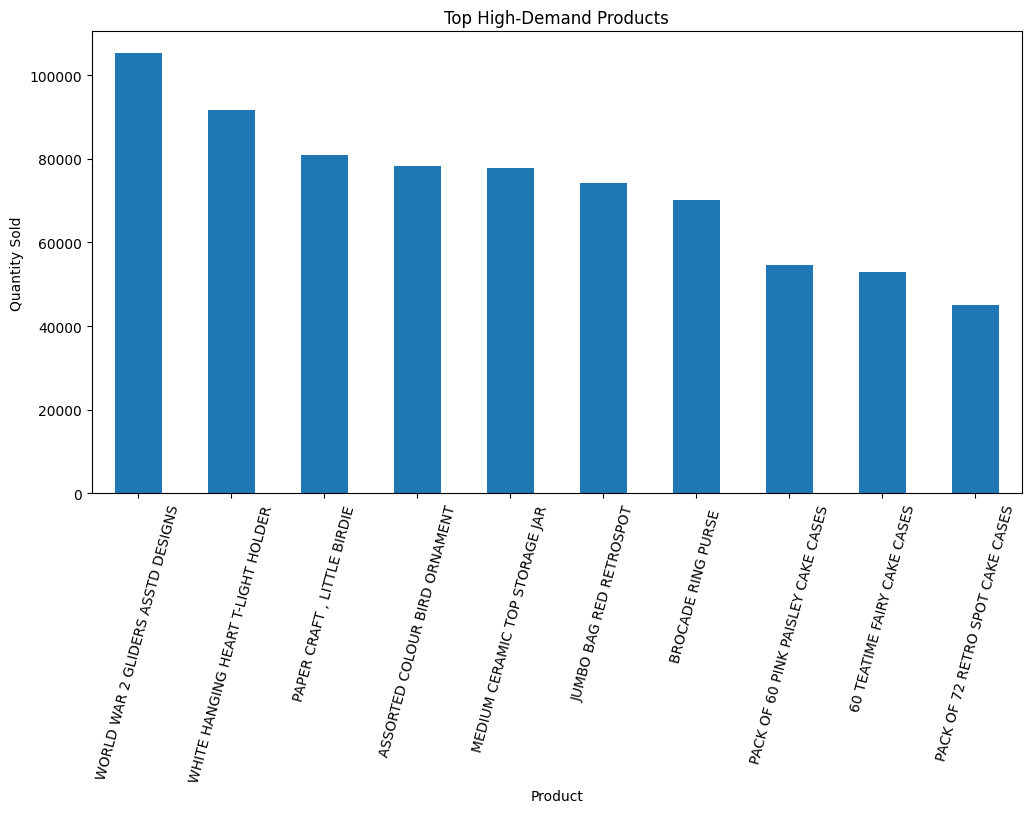

In [117]:
plt.figure(figsize=(12,6))

top_inventory['Total_Quantity_Sold'].plot(kind='bar')

plt.title("Top High-Demand Products")

plt.xlabel("Product")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=75)

plt.show()

In [118]:
#Reorder Point = Average Daily Demand × Lead Time

In [119]:
inventory['Avg_Daily_Demand'] = (
    inventory['Total_Quantity_Sold'] / 30
)

In [120]:
# Assume Lead Time

#Example-7 days
lead_time = 7

inventory['Reorder_Point'] = (
    inventory['Avg_Daily_Demand'] * lead_time
)

In [121]:
inventory.head()

,Total_Quantity_Sold,Total_Orders,Total_Revenue,Avg_Daily_Demand,Reorder_Point
Description,,,,,
DOORMAT UNION JACK GUNS AND ROSES,167,51,1071.25,5.566667,38.966667
3 STRIPEY MICE FELTCRAFT,662,112,1241.10,22.066667,154.466667
4 PURPLE FLOCK DINNER CANDLES,324,51,495.16,10.800000,75.600000
50'S CHRISTMAS GIFT BAG LARGE,1885,109,2272.25,62.833333,439.833333
ANIMAL STICKERS,385,12,80.85,12.833333,89.833333


In [122]:
inventory.to_csv('inventory_analysis.csv')

# Inventory Optimization

Inventory optimization was performed using product demand analysis and reorder point calculations.

Key inventory metrics were calculated:
- Total quantity sold
- Total orders
- Product revenue
- Average daily demand

A simple reorder point formula was used:

Reorder Point = Average Daily Demand × Lead Time

This analysis helps businesses:
- Prevent stock shortages
- Improve inventory planning
- Identify high-demand products
- Optimize supply chain operations

# # Advanced EDA & Business Insights

# Correlation Heatmap

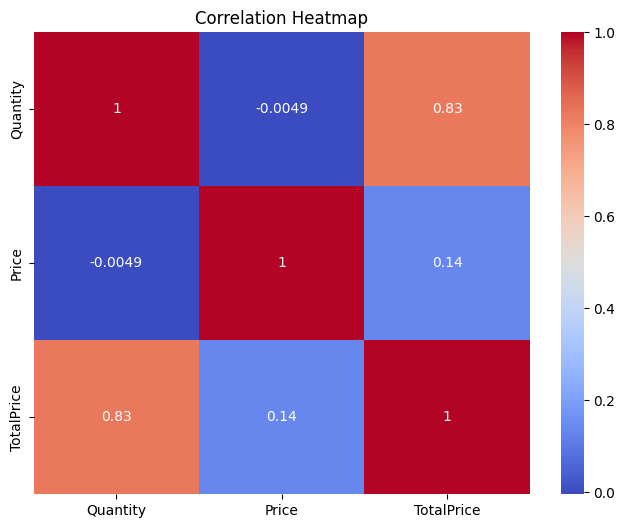

In [123]:
plt.figure(figsize=(8,6))

sns.heatmap(
    retail[['Quantity', 'Price', 'TotalPrice']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Sales by Day of Week

In [124]:
retail['DayName'] = retail['InvoiceDate'].dt.day_name()

In [125]:
day_sales = retail.groupby('DayName')['TotalPrice'].sum()

day_sales = day_sales.reindex([
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
])



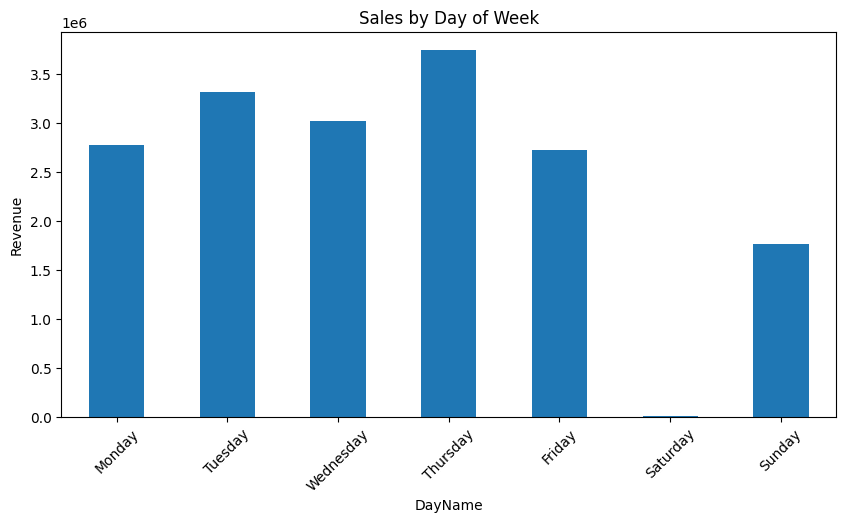

In [126]:
plt.figure(figsize=(10,5))

day_sales.plot(kind='bar')

plt.title("Sales by Day of Week")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# Monthly Orders Trend

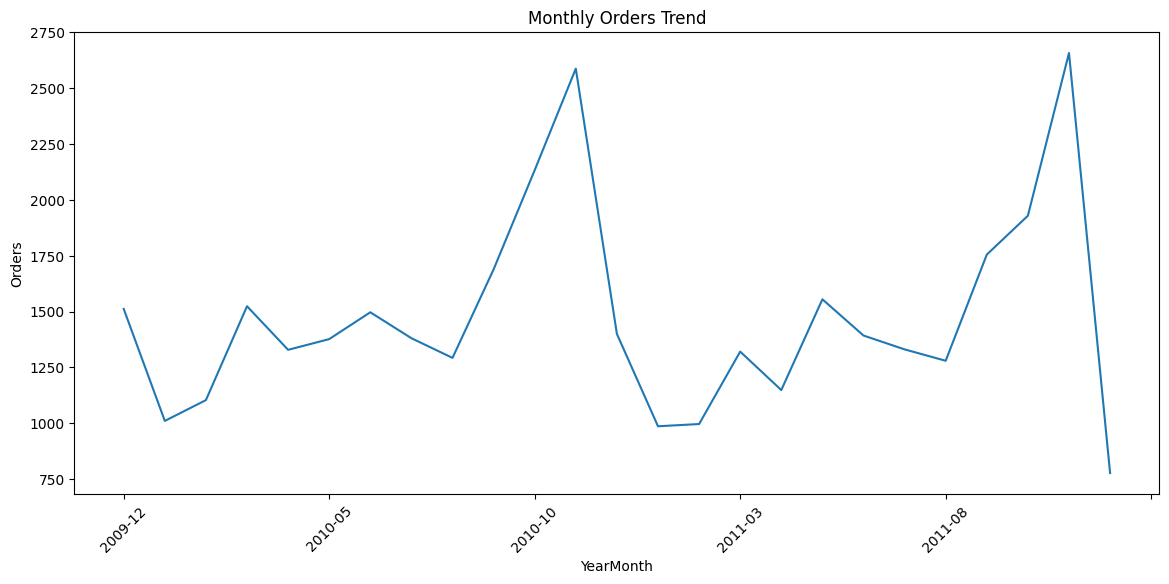

In [127]:
monthly_orders = retail.groupby('YearMonth')['Invoice'].nunique()

monthly_orders.index = monthly_orders.index.astype(str)

plt.figure(figsize=(14,6))

monthly_orders.plot()

plt.title("Monthly Orders Trend")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

# 4. Top Countries by Orders

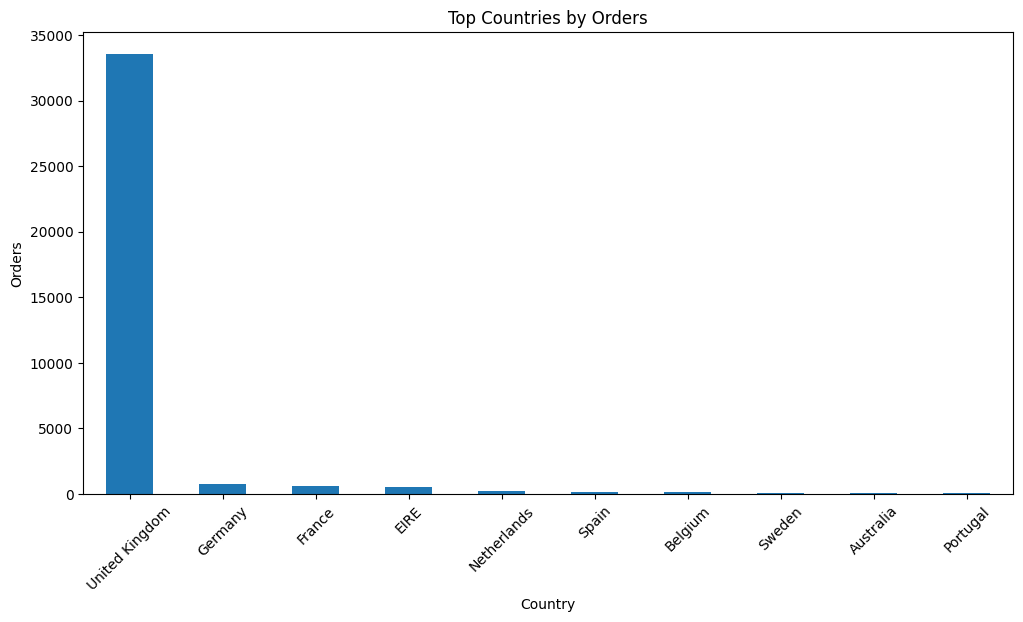

In [128]:
country_orders = retail.groupby('Country')['Invoice'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

country_orders.plot(kind='bar')

plt.title("Top Countries by Orders")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

# 5. Return Analysis

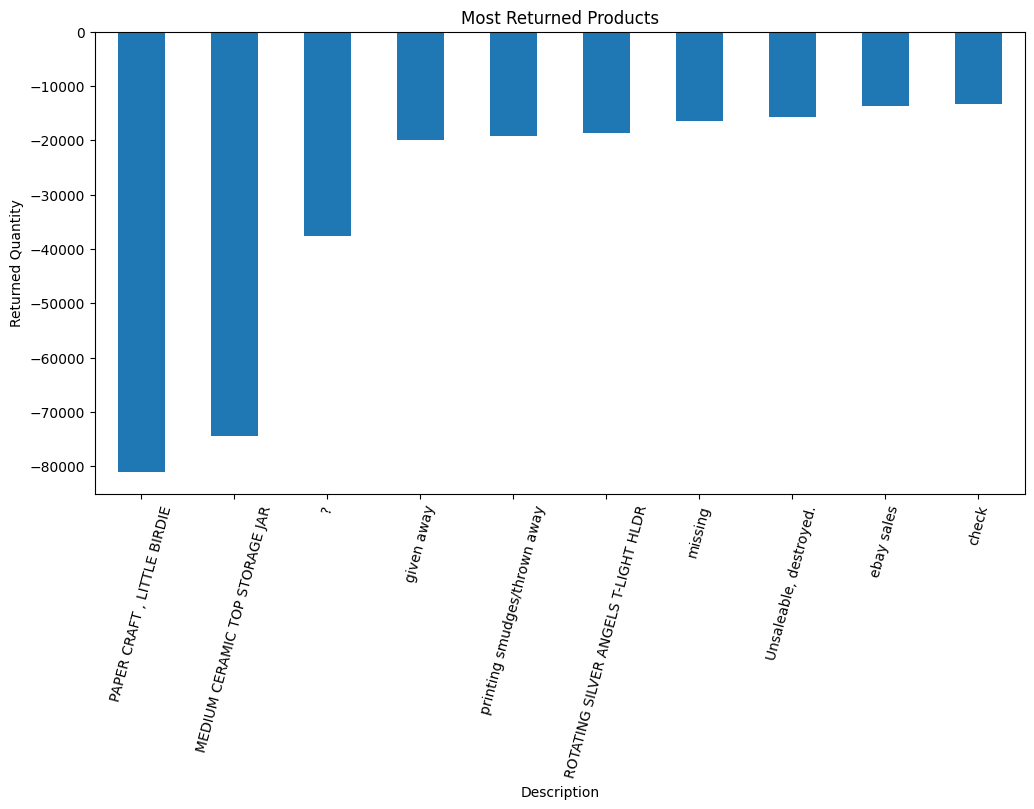

In [129]:
top_returns = returns_df.groupby('Description')['Quantity'].sum().sort_values().head(10)

plt.figure(figsize=(12,6))

top_returns.plot(kind='bar')

plt.title("Most Returned Products")

plt.ylabel("Returned Quantity")

plt.xticks(rotation=75)

plt.show()

#  Conclusion

This project successfully analyzed large-scale retail transaction data using data analytics and machine learning techniques.

Key tasks performed:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Advanced business insights generation
- Customer segmentation using RFM analysis
- Machine Learning-based clustering using KMeans
- Demand forecasting using Prophet
- Customer churn prediction using classification models
- Inventory optimization using demand analysis

Major insights identified:
- Retail sales show strong seasonal patterns
- A small group of VIP customers contributes significantly to total revenue
- Bulk purchases heavily influence revenue distribution
- Churn prediction can help identify inactive customers for retention strategies
- Inventory optimization can support stock planning and demand management

The project demonstrates how machine learning and analytics can support retail business decision-making and customer intelligence systems.

# # Future Scope

Future improvements for the project may include:
- LSTM-based deep learning forecasting models
- SHAP explainability for churn prediction
- Real-time data pipelines using Kafka
- Workflow orchestration using Apache Airflow
- Experiment tracking using MLflow
- Cloud deployment using AWS or Azure
- Real-time recommendation systems
- Automated inventory alert systems

The project can be further expanded into a production-grade retail intelligence platform with scalable MLOps integration.

In [130]:
import os
os.listdir('/kaggle/working')

['inventory_analysis.csv',
 'returns_data.csv',
 'sales_forecast.csv',
 '.virtual_documents',
 'cleaned_retail_data.csv',
 'rfm_customer_segments.csv',
 'customer_churn_analysis.csv']

# Cohort Analysis

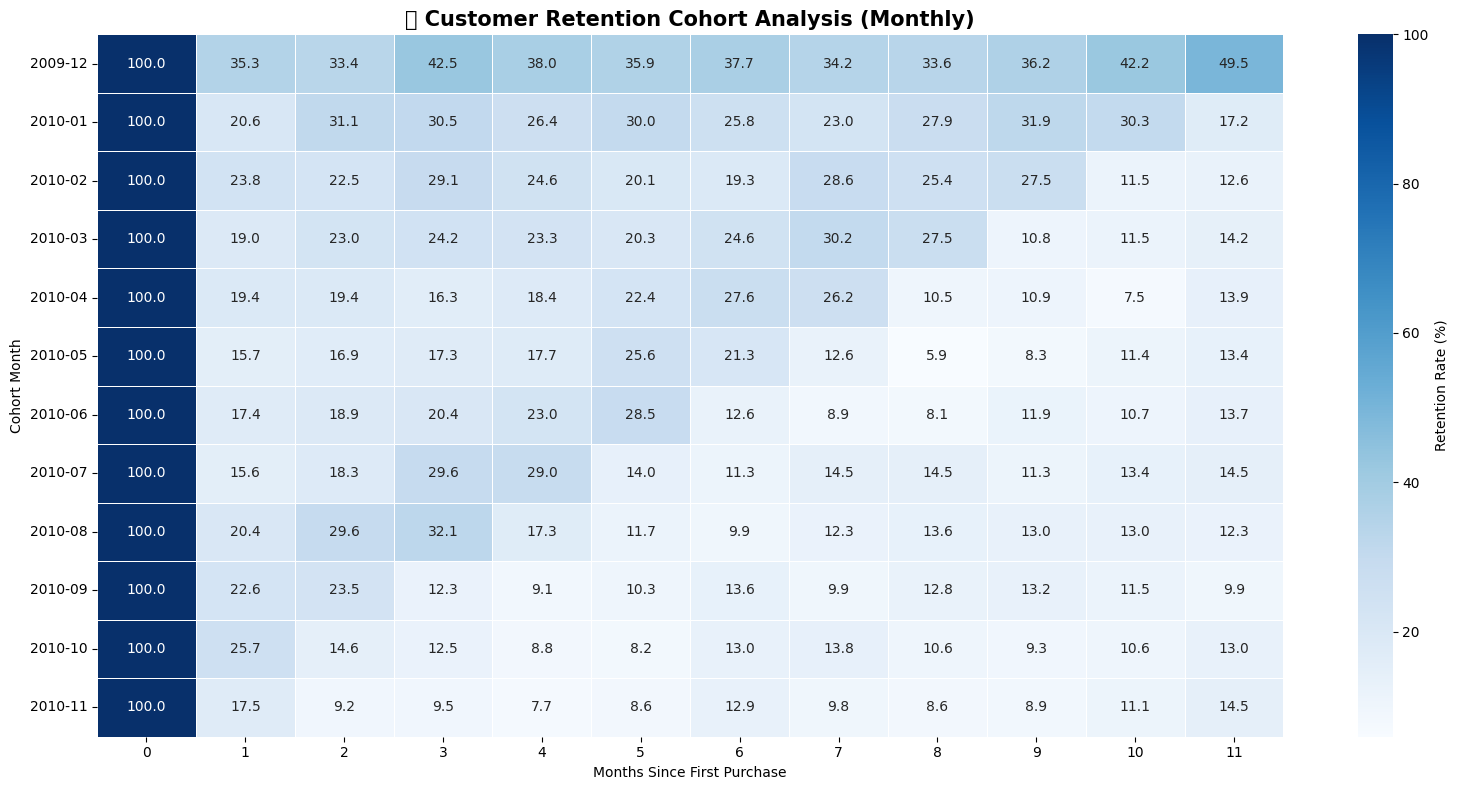

✅ Cohort Analysis Complete!
Average Month-1 Retention Rate: 21.2%


In [131]:
# Cohort Analysis

# Step 1: First Purchase Month of each customer
retail['OrderMonth'] = retail['InvoiceDate'].dt.to_period('M')

cohort_data = retail.groupby('Customer ID')['OrderMonth'].min().reset_index()
cohort_data.columns = ['Customer ID', 'CohortMonth']

# Step 2: Merge with main data
retail_cohort = retail.merge(cohort_data, on='Customer ID')

# Step 3: Calculate Cohort Index (months since first purchase)
retail_cohort['CohortIndex'] = (
    retail_cohort['OrderMonth'].dt.year * 12 + retail_cohort['OrderMonth'].dt.month
) - (
    retail_cohort['CohortMonth'].dt.year * 12 + retail_cohort['CohortMonth'].dt.month
)

# Step 4: Cohort Table
cohort_table = retail_cohort.groupby(
    ['CohortMonth', 'CohortIndex']
)['Customer ID'].nunique().unstack()

# Step 5: Retention Rate
cohort_size = cohort_table.iloc[:, 0]
retention_table = cohort_table.divide(cohort_size, axis=0) * 100

# Step 6: Visualize
plt.figure(figsize=(16, 8))
sns.heatmap(
    retention_table.iloc[:12, :12],
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)
plt.title('📊 Customer Retention Cohort Analysis (Monthly)', fontsize=15, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

print("✅ Cohort Analysis Complete!")
print(f"Average Month-1 Retention Rate: {retention_table.iloc[:, 1].mean():.1f}%")


**Cohort Analysis Insights:**

- Row = vo month jab customers pehli baar aaye (Cohort Month)
- Column = unke aane ke baad kitne months baad wapas aaye (0, 1, 2, ...)
- Column 0 = hamesha 100% (khud wahi month hai)
- Percentage = us cohort ke kitne % customers wapas aaye

**Business Value:**
- Agar Month-1 retention low hai → onboarding improve karo
- Agar certain cohorts zyada retain hote hain → us time ka campaign analyze karo

# 🛒 Market Basket Analysis (Association Rules)



In [132]:
# Market Basket Analysis
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    mlxtend_available = True
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'mlxtend', '-q'])
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    mlxtend_available = True

# Step 1: Prepare basket data - Top countries ke liye
basket_data = retail[retail['Country'].isin(['United Kingdom', 'Germany', 'France'])]

# Step 2: Create Invoice-Product Matrix (limit for performance)
# Pehle wale code mein sirf 100 products aur 3000 invoices lene se
# combinations bahut sparse ho jaate the -> isliye 0 rules aa rahe the.
# Yahan thoda bada sample le rahe hain taaki co-occurring items milein.
basket = (basket_data
          .groupby(['Invoice', 'Description'])['Quantity']
          .sum()
          .unstack()
          .fillna(0)
          .iloc[:5000, :150])  # thoda bada sample - better chance of overlap

# Step 3: Convert to binary (bought or not) - bool dtype use karo
# (int ki jagah bool, warna mlxtend deprecation warning deta hai
# aur performance bhi kharab hoti hai)
basket_encoded = basket.map(lambda x: True if x > 0 else False) if hasattr(basket, 'map') else basket.applymap(lambda x: True if x > 0 else False)

# Step 4: Apply Apriori Algorithm - dynamic min_support
# Agar high min_support (0.03) pe sirf single items (length=1) milte hain,
# toh association_rules ko length>=2 wale itemsets nahi milte -> 0 rules.
# Isliye hum support ko step-by-step kam karte hain jab tak
# multi-item (length >= 2) itemsets na mil jaayein.
support_candidates = [0.03, 0.02, 0.01, 0.007, 0.005, 0.003, 0.002]
frequent_itemsets = pd.DataFrame()
used_support = None

for sup in support_candidates:
    fi = apriori(basket_encoded, min_support=sup, use_colnames=True)
    if len(fi) == 0:
        continue
    fi['length'] = fi['itemsets'].apply(len)
    used_support = sup
    frequent_itemsets = fi
    if (fi['length'] >= 2).any():
        # multi-item itemsets mil gaye, ab rules ban sakte hain
        break

print(f"ℹ️ Used min_support = {used_support}")
print(f"ℹ️ Total frequent itemsets = {len(frequent_itemsets)}")
if len(frequent_itemsets) > 0:
    print("ℹ️ Itemset length distribution:")
    print(frequent_itemsets['length'].value_counts().sort_index())
print()

# Step 5: Generate Association Rules
rules = pd.DataFrame()
if len(frequent_itemsets) > 0 and (frequent_itemsets['length'] >= 2).any():
    # Pehle lift try karo, agar phir bhi 0 aaye toh threshold aur kam karo
    for lift_threshold in [1.2, 1.05, 1.0]:
        rules = association_rules(frequent_itemsets, metric='lift', min_threshold=lift_threshold)
        if len(rules) > 0:
            break
    # Agar lift-based rules phir bhi na milein, confidence pe fallback karo
    if len(rules) == 0:
        rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.2)

    if len(rules) > 0:
        rules = rules.sort_values('lift', ascending=False)

print(f"✅ Total Association Rules Found: {len(rules)}")
print()
if len(rules) > 0:
    print("🏆 Top 10 Product Association Rules:")
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string())
else:
    print("⚠️ Abhi bhi 0 rules aa rahe hain. Basket size aur badhao ya")
    print("   min_support aur kam karo (e.g. 0.001) - dataset zyada sparse ho sakta hai.")

ℹ️ Used min_support = 0.01
ℹ️ Total frequent itemsets = 21
ℹ️ Itemset length distribution:
length
1    20
2     1
Name: count, dtype: int64

✅ Total Association Rules Found: 2

🏆 Top 10 Product Association Rules:
                          antecedents                         consequents  support  confidence      lift
0       (12 PENCILS SMALL TUBE SKULL)  (12 PENCILS SMALL TUBE RED SPOTTY)   0.0114    0.527778  22.94686
1  (12 PENCILS SMALL TUBE RED SPOTTY)       (12 PENCILS SMALL TUBE SKULL)   0.0114    0.495652  22.94686


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

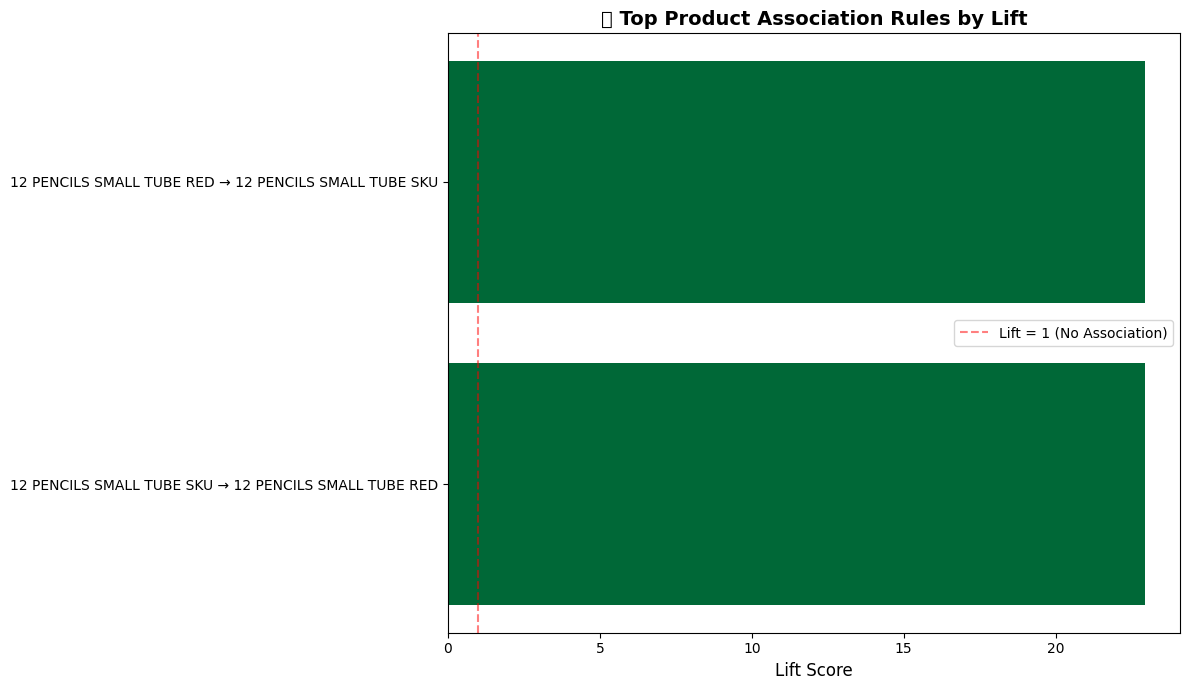

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

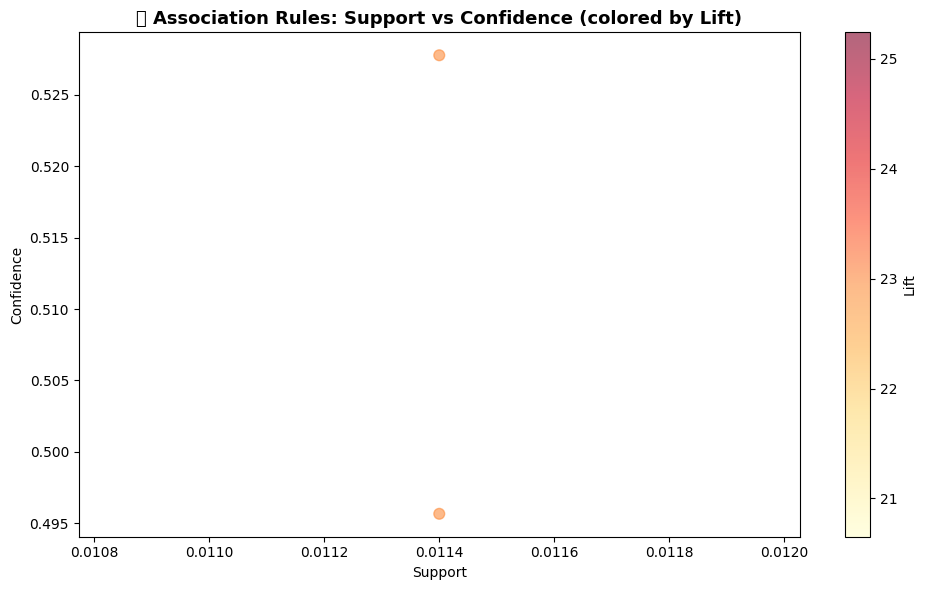

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [133]:
# Visualize Top Rules

top_rules = rules.head(15).copy()
top_rules['rule'] = top_rules.apply(
    lambda x: f"{list(x['antecedents'])[0][:25]} → {list(x['consequents'])[0][:25]}", axis=1
)

plt.figure(figsize=(12, 7))
bars = plt.barh(top_rules['rule'], top_rules['lift'], color=plt.cm.RdYlGn(top_rules['lift'] / top_rules['lift'].max()))
plt.xlabel('Lift Score', fontsize=12)
plt.title('🛒 Top Product Association Rules by Lift', fontsize=14, fontweight='bold')
plt.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='Lift = 1 (No Association)')
plt.legend()
plt.tight_layout()
plt.show()

# Scatter Plot: Support vs Confidence
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    s=60,
    alpha=0.6
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('📊 Association Rules: Support vs Confidence (colored by Lift)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Market Basket Analysis Insights:**

- **High Lift Rules** → In products ko saath promote karo (bundle offers)
- **High Confidence** → Agar customer A khareede, toh B suggest karo (recommendation system)
- **Business Action** → "Frequently bought together" section implement karo (Amazon style!)

# 💰 Customer Lifetime Value (CLV) Prediction



In [134]:
# Customer Lifetime Value (CLV) Calculation

# Step 1: Base Metrics per Customer
clv_data = retail.groupby('Customer ID').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Total_Orders=('Invoice', 'nunique'),
    Avg_Order_Value=('TotalPrice', 'mean'),
    First_Purchase=('InvoiceDate', 'min'),
    Last_Purchase=('InvoiceDate', 'max')
).reset_index()

# Step 2: Customer Lifespan in days
clv_data['Lifespan_Days'] = (
    clv_data['Last_Purchase'] - clv_data['First_Purchase']
).dt.days + 1

clv_data['Lifespan_Months'] = clv_data['Lifespan_Days'] / 30

# Step 3: Purchase Frequency (orders per month)
clv_data['Purchase_Frequency'] = (
    clv_data['Total_Orders'] / clv_data['Lifespan_Months'].clip(lower=1)
)

# Step 4: CLV Score (projected for 12 months)
clv_data['CLV_12M'] = (
    clv_data['Avg_Order_Value'] *
    clv_data['Purchase_Frequency'] *
    12
)

# Step 5: CLV Segment
clv_data['CLV_Segment'] = pd.qcut(
    clv_data['CLV_12M'],
    q=4,
    labels=['Low Value', 'Medium Value', 'High Value', 'Premium']
)

print("✅ CLV Calculation Complete!")
print(clv_data[['Customer ID', 'Total_Revenue', 'Total_Orders', 'CLV_12M', 'CLV_Segment']].head(10))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ CLV Calculation Complete!
   Customer ID  Total_Revenue  Total_Orders       CLV_12M CLV_Segment
0      12346.0       77556.46            12  24574.146047     Premium
1      12347.0        4921.53             8    158.428972  High Value
2      12348.0        2019.40             5    196.344191  High Value
3      12349.0        4428.69             4     63.821002   Low Value
4      12350.0         334.40             1    236.047059  High Value
5      12351.0         300.93             1    171.960000  High Value
6      12352.0        2849.84            10    279.008567     Premium
7      12353.0         406.76             2     59.525854   Low Value
8      12354.0        1079.40             1    223.324138  High Value
9      12355.0         947.61             2     55.066925   Low Value


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

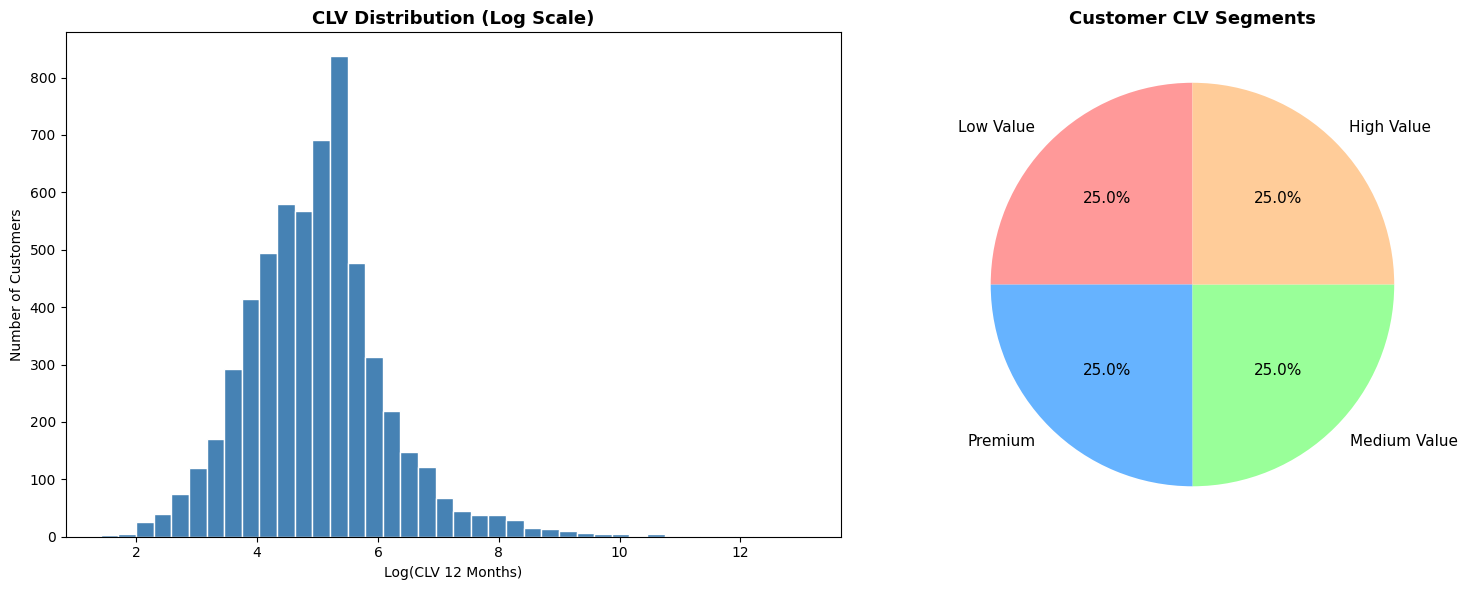

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

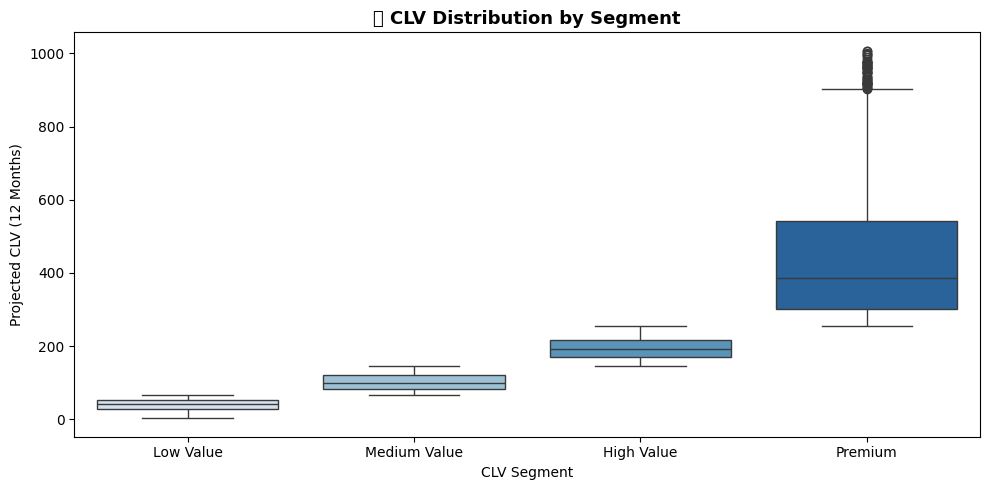

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



📊 CLV Summary by Segment:
               count     mean       std     min     25%     50%     75%  \
CLV_Segment                                                               
Low Value     1470.0    40.39     16.40    3.11   28.19   41.47   54.03   
Medium Value  1469.0   102.47     22.21   67.93   82.85   99.43  121.57   
High Value    1469.0   194.15     29.18  145.06  170.01  192.14  216.28   
Premium       1470.0  1996.58  15131.07  254.29  320.26  449.96  848.83   

                    max  
CLV_Segment              
Low Value         67.83  
Medium Value     145.06  
High Value       254.27  
Premium       478998.00  

✅ CLV data saved!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [135]:
# CLV Visualizations

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: CLV Distribution
axes[0].hist(np.log1p(clv_data['CLV_12M']), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('CLV Distribution (Log Scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Log(CLV 12 Months)')
axes[0].set_ylabel('Number of Customers')

# Plot 2: CLV Segment Distribution
segment_counts = clv_data['CLV_Segment'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
axes[1].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
           colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Customer CLV Segments', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# CLV by Segment - Box Plot
plt.figure(figsize=(10, 5))
clv_plot = clv_data[clv_data['CLV_12M'] < clv_data['CLV_12M'].quantile(0.95)]
sns.boxplot(x='CLV_Segment', y='CLV_12M', data=clv_plot,
            order=['Low Value', 'Medium Value', 'High Value', 'Premium'],
            palette='Blues')
plt.title('💰 CLV Distribution by Segment', fontsize=13, fontweight='bold')
plt.xlabel('CLV Segment')
plt.ylabel('Projected CLV (12 Months)')
plt.tight_layout()
plt.show()

print(f"\n📊 CLV Summary by Segment:")
print(clv_data.groupby('CLV_Segment')['CLV_12M'].describe().round(2))

clv_data.to_csv('clv_analysis.csv', index=False)
print("\n✅ CLV data saved!")


# Final Project Summary - NeuralRetail Intelligence Platform

## Complete Module Overview

| # | Module | Technique | Business Value |
|---|--------|-----------|----------------|
| 1 | Data Cleaning | Pandas, Feature Engineering | Clean ML-ready data |
| 2 | EDA | Matplotlib, Seaborn | Business KPI Insights |
| 3 | RFM Segmentation | Quantile Scoring | Customer Value Ranking |
| 4 | KMeans Clustering | Scikit-learn | Automatic Customer Groups |
| 5 | Demand Forecasting | Prophet | Statistical Sales Forecast |
| 6 | Churn Prediction | Logistic Reg, RF, XGBoost | At-risk Customer Detection |
| 7 | Inventory Optimization | Reorder Point Formula | Stock Planning |
| 8 | Cohort Analysis | Retention Heatmap | Customer Loyalty Tracking |
| 9 | Market Basket Analysis | Apriori Algorithm | Cross-sell Opportunities |
| 10 | CLV Prediction | Formula + Segmentation | Future Revenue per Customer |

## Technologies Used
Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost,
Prophet, mlxtend

Developed by Snehaa Gupta
